In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#show all columns
pd.set_option("display.max_columns", 100)

#get the data and show beginning to conceptualize
data = pd.read_csv("credit_cards_2025-post (2).csv")
data.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,17270,130000,2,2,1,34,0,0,0,0,0,0,99891,101032,104705,105478,107725,109994,3700,5300,4000,4000,4000,6100,0
1,22364,290000,2,1,2,27,-1,-1,0,0,0,0,168,569,1401,1503,834,931,569,1000,1000,200,265,500,0
2,23880,360000,1,1,2,27,-2,-2,-2,-2,-2,-2,2807,894,5939,1390,-5,-5,898,5970,1396,0,0,0,0
3,9074,110000,2,1,2,35,-1,2,-1,0,0,-1,549,179,1166,790,806,1729,0,1166,0,446,1729,0,0
4,25083,260000,1,3,1,48,0,0,0,0,0,0,154927,158848,160654,155059,141570,134143,8000,6000,7100,5300,5000,5000,0
5,5239,380000,1,1,1,32,0,0,0,0,0,0,53369,73954,35199,31136,28839,14584,30307,5044,5036,5081,2022,2026,0
6,17809,10000,1,2,2,24,3,2,2,3,3,3,1050,1050,1050,1050,1050,1050,0,0,0,0,0,0,1
7,10159,500000,2,2,2,36,-2,-2,-2,-2,-2,-2,11168,9287,9963,17145,7645,16079,9287,9963,17223,7645,16079,11288,0
8,7681,220000,1,2,1,49,0,0,0,0,0,0,153880,143020,117567,153069,153045,144529,6300,4500,37486,6000,5200,5002,0
9,1636,80000,1,3,2,29,0,0,0,0,0,0,46638,47680,48395,49356,50560,51431,2091,1806,1767,2000,1767,1740,0


In [3]:
#task 1
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#standardize, then perform PCA to get three dimensions from 14

dimensions = ["AGE", "LIMIT_BAL", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

#get numeric copy to protect data
dimensions1 = data[dimensions].copy()

#standardize data
scaler = StandardScaler()
standardized = scaler.fit_transform(dimensions1)

#perform pca to get three dimensions
pca = PCA(n_components=3)
new_dimensions = pca.fit_transform(standardized)

#create new dataframe for pca'd data
labels = ["NEW1", "NEW2", "NEW3"]
pca_data = pd.DataFrame(new_dimensions, columns=labels)

#show first 5
print(pca_data.shape)
pca_data.head(5)



(24000, 3)


,NEW1,NEW2,NEW3
0,2.030105,-0.908633,0.319742
1,-1.587407,0.185636,0.263450
2,-1.444669,0.415575,0.097748
3,-1.790438,-0.160231,0.025366
4,3.895848,-0.884615,-1.271163


In [4]:
from sklearn.preprocessing import MinMaxScaler

#perform minmax normalization
scaler = MinMaxScaler()
normalized = scaler.fit_transform(pca_data)

#create new dataframe
norm_data = pd.DataFrame(normalized, columns=["NEW1", "NEW2", "NEW3"])

#print results
print(norm_data.shape)
norm_data.head(5)

(24000, 3)


,NEW1,NEW2,NEW3
0,0.125607,0.045850,0.164771
1,0.038353,0.059200,0.162904
2,0.041796,0.062006,0.157407
3,0.033456,0.054981,0.155005
4,0.170608,0.046143,0.111995


In [5]:
#Task 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select "k" random points from "data" as the initial centroids.
def rand_center(data,k):
    #make numpy array
    array = np.asarray(data)

    #get num of points
    num = array.shape[0]

    #select random centroids by index
    i = np.random.choice(num, size=k, replace=False)

    #get centroid from index
    centroids = array[i, :]
    return centroids


#check whether centroids1==centroids2
def converged(centroids1, centroids2):

    if not hasattr(converged, "counter"):
        converged.counter = 0
    converged.counter += 1

    if converged.counter >= 100:
        print("infinte loop")
        return True

    return np.allclose(centroids1, centroids2, atol=1e-4)


#Assign each data point to its nearest centroid based on the Euclidean distance
#Update the cluster centroid to the mean of all the points assigned to that cluster
def update_centroids(data, centroids, k):
    
    array = np.asarray(data)

    if k is None:
        k = centroids.shape[0]

    diff = array[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)

    labels = np.argmin(dist, axis=1)

    new_centroids = np.zeros_like(centroids)
    for i in range(k):
        cluster_points = array[labels == i]
        if cluster_points.shape[0] > 0:
            new_centroids[i] = cluster_points.mean(axis=0)
        else:
            #if a cluster gets no points, reinitialize that centroid randomly
            rand_idx = np.random.randint(array.shape[0])
            new_centroids[i] = array[rand_idx]
    
    return new_centroids, labels



In [6]:
def kmeans(data,k=5):
    #reset counter
    if hasattr(converged, "counter"):
        converged.counter = 0
    
    # step 1:
    centroids = rand_center(data,k)
    converge = False
    while not converge:
        old_centroids = np.copy(centroids)
        # step 2 & 3; labels can be an array of labels for all the data points
        centroids, label = update_centroids(data, old_centroids, k)
        # step 4
        converge = converged(old_centroids, centroids)
    print(">>> final centroids")
    print(centroids)
    return centroids, label

In [21]:
def bisecting_kmeans(data, k = 5):
    #make numpy array
    array = np.asarray(data)
    num = array.shape[0]

    #init single cluster with all points
    clusters = [np.arange(num)]

    #perform split on largest cluster until we have k
    while len(clusters) < k:

        #get the largest cluster
        sizes = [len(i) for i in clusters]
        split = np.argmax(sizes)
        split_i = clusters[split]

        #get that clusters points
        cluster_data = array[split_i]
        #perform kmeans with k=2 on that cluster
        new_centroids, new_labels = kmeans(cluster_data, k=2)

        #create new clusters and split points respectively
        child0 = split_i[new_labels == 0]
        child1 = split_i[new_labels == 1]

        #replace old cluster, add other new cluster
        clusters[split] = child0
        clusters.append(child1)

    #build final array and matrix
    final_labels = np.zeros(num, dtype=int)
    final_centroids = np.zeros((len(clusters), array.shape[1]))

    for cluster_id, i in enumerate(clusters):
        final_labels[i] = cluster_id
        pts = array[i]
        final_centroids[cluster_id] = pts.mean(axis=0)

    return final_centroids, final_labels

In [15]:
def sse(data, labels, centroids):
    #create NumPy array
    data1 = np.asarray(data)
    labels1 = np.asarray(labels)
    centroids1 = np.asarray(centroids)

    #init sse to 0
    sse = 0.0

    #iterate over each cluster, find dist from each point to its centroid
    k = centroids1.shape[0]
    for i in range(k):
        pts = data1[labels1 == i]
        #get dist for each point to centroid
        dist = pts - centroids1[i]
        #square the dist and sum over each point
        sse += np.sum(dist ** 2)
    return sse

run 1
>>> final centroids
[[0.04896671 0.05491035 0.17870558]
 [0.19747586 0.05297491 0.15060211]
 [0.35297505 0.05460795 0.1508598 ]
 [0.11278836 0.05734051 0.15993003]
 [0.05151752 0.06034245 0.12119993]]
run 2
>>> final centroids
[[0.05609137 0.0616273  0.10556406]
 [0.05064165 0.05857677 0.14810996]
 [0.05386209 0.0537165  0.18747962]
 [0.1427337  0.0554758  0.15642658]
 [0.2868036  0.05402451 0.14990816]]
run 3
>>> final centroids
[[0.05387762 0.05371647 0.18744028]
 [0.14273435 0.05547526 0.1564505 ]
 [0.05061912 0.05858783 0.14806945]
 [0.2868036  0.05402451 0.14990816]
 [0.05611578 0.06162436 0.10554386]]
run 4
>>> final centroids
[[0.05052744 0.05857953 0.14767105]
 [0.2876125  0.05413203 0.1498112 ]
 [0.14335386 0.0554176  0.15643957]
 [0.05406343 0.05374354 0.1872478 ]
 [0.0564712  0.06173578 0.10520703]]
run 5
>>> final centroids
[[0.05055525 0.05858056 0.14807348]
 [0.05605677 0.06162351 0.10555039]
 [0.28664189 0.0540084  0.14990813]
 [0.05385415 0.05371609 0.18744686]
 [

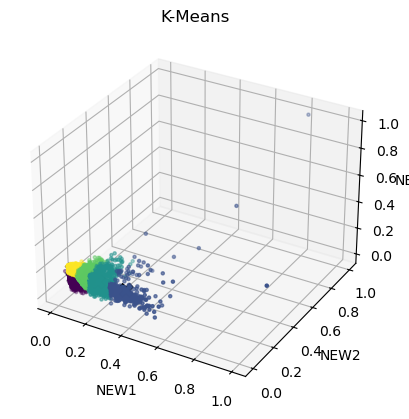

In [29]:
#Task 3
#run my kmeans 20 times, keep best sse

k = 5
runs = 20

#init results
sses = []
best_sse = float("inf")
best_centroids = None
best_labels = None

#perform runs
for i in range(runs):
    print(f"run {i+1}")
    centroids, labels = kmeans(norm_data, k=k)
    sse1 = sse(norm_data, labels, centroids)
    sses.append(sse1)

    #check if best run
    if sse1 < best_sse:
        best_sse = sse1
        best_centroids = centroids
        best_labels = labels

print("best sse:", best_sse)

#create graph
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    norm_data["NEW1"],
    norm_data["NEW2"],
    norm_data["NEW3"],
    c=best_labels,
    s=5
)

# plot centroids on top
ax.scatter(
    best_centroids[:, 0],
    best_centroids[:, 1],
    best_centroids[:, 2],
    marker="X",
    s=100,
    edgecolors="black"
)

ax.set_title("K-Means")
ax.set_xlabel("NEW1")
ax.set_ylabel("NEW2")
ax.set_zlabel("NEW3")

plt.show()

run 1
>>> final centroids
[[0.05729951 0.05727464 0.1543123 ]
 [0.194555   0.05486879 0.15325984]]
>>> final centroids
[[0.05775864 0.05496922 0.17837192]
 [0.05670319 0.06026893 0.12306351]]
>>> final centroids
[[0.09060185 0.05520405 0.17678006]
 [0.04499563 0.05487797 0.17899052]]
>>> final centroids
[[0.04617981 0.05972211 0.12265254]
 [0.09036715 0.06201819 0.12437819]]
run 2
>>> final centroids
[[0.194555   0.05486879 0.15325984]
 [0.05729951 0.05727464 0.1543123 ]]
>>> final centroids
[[0.05669583 0.06026825 0.12307918]
 [0.05776476 0.05496747 0.17838359]]
>>> final centroids
[[0.04498035 0.05487655 0.17900024]
 [0.09055958 0.05520068 0.17680176]]
>>> final centroids
[[0.09032858 0.06202154 0.12434613]
 [0.04616406 0.05971923 0.12268244]]
run 3
>>> final centroids
[[0.19483989 0.05484364 0.15332337]
 [0.05734614 0.05727711 0.15430122]]
>>> final centroids
[[0.05679788 0.06027882 0.12307106]
 [0.05776876 0.05496328 0.17837452]]
>>> final centroids
[[0.04498192 0.05487675 0.178980

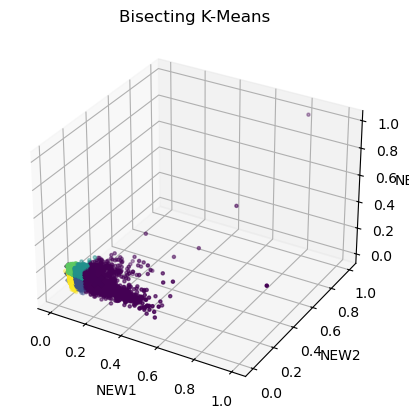

In [31]:
#run my bisecting kmeans 20 times, keep best sse

k = 5
runs = 5

#init results
sses = []
best_sse = float("inf")
best_centroids = None
best_labels = None

#perform runs
for i in range(runs):
    print(f"run {i+1}")
    centroids, labels = bisecting_kmeans(norm_data, k=k)
    sse1 = sse(norm_data, labels, centroids)
    sses.append(sse1)

    #check if best run
    if sse1 < best_sse:
        best_sse = sse1
        best_centroids = centroids
        best_labels = labels

print("best sse:", best_sse)

#create graph
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    norm_data["NEW1"],
    norm_data["NEW2"],
    norm_data["NEW3"],
    c=best_labels,
    s=5
)

# plot centroids on top
ax.scatter(
    best_centroids[:, 0],
    best_centroids[:, 1],
    best_centroids[:, 2],
    marker="X",
    s=100,
    edgecolors="black"
)

ax.set_title("Bisecting K-Means")
ax.set_xlabel("NEW1")
ax.set_ylabel("NEW2")
ax.set_zlabel("NEW3")

plt.show()

sse: 28.875994542723


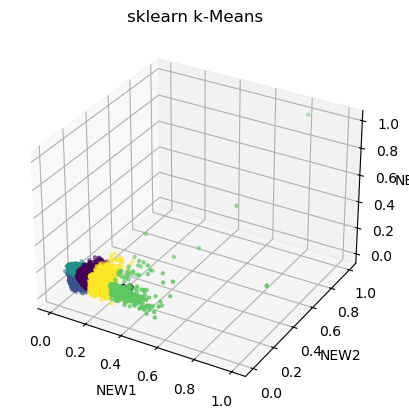

In [30]:
#run sklearn kmeans 1
from sklearn.cluster import KMeans

k = 5

kmeans_sklearn = KMeans(n_clusters=k, n_init=10, init="k-means++", random_state=0)
kmeans_sklearn.fit(norm_data)

centroids = kmeans_sklearn.cluster_centers_
labels = kmeans_sklearn.labels_

sse1 = sse(norm_data, labels, centroids)

print("sse:", sse1)

#get graph
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    norm_data["NEW1"],
    norm_data["NEW2"],
    norm_data["NEW3"],
    c=labels,
    s=5
)

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    marker="X",
    s=100,
    edgecolors="black"
)

ax.set_title("sklearn k-Means")
ax.set_xlabel("NEW1")
ax.set_ylabel("NEW2")
ax.set_zlabel("NEW3")

plt.show()